# Applied Question 13 — Weekly Data

## (a) Numerical and Graphical Summaries

              Year         Lag1         Lag2         Lag3         Lag4  \
count  1089.000000  1089.000000  1089.000000  1089.000000  1089.000000   
mean   2000.048669     0.150585     0.151079     0.147205     0.145818   
std       6.033182     2.357013     2.357254     2.360502     2.360279   
min    1990.000000   -18.195000   -18.195000   -18.195000   -18.195000   
25%    1995.000000    -1.154000    -1.154000    -1.158000    -1.158000   
50%    2000.000000     0.241000     0.241000     0.241000     0.238000   
75%    2005.000000     1.405000     1.409000     1.409000     1.409000   
max    2010.000000    12.026000    12.026000    12.026000    12.026000   

              Lag5       Volume        Today  
count  1089.000000  1089.000000  1089.000000  
mean      0.139893     1.574618     0.149899  
std       2.361285     1.686636     2.356927  
min     -18.195000     0.087465   -18.195000  
25%      -1.166000     0.332022    -1.154000  
50%       0.234000     1.002680     0.241000  
75% 

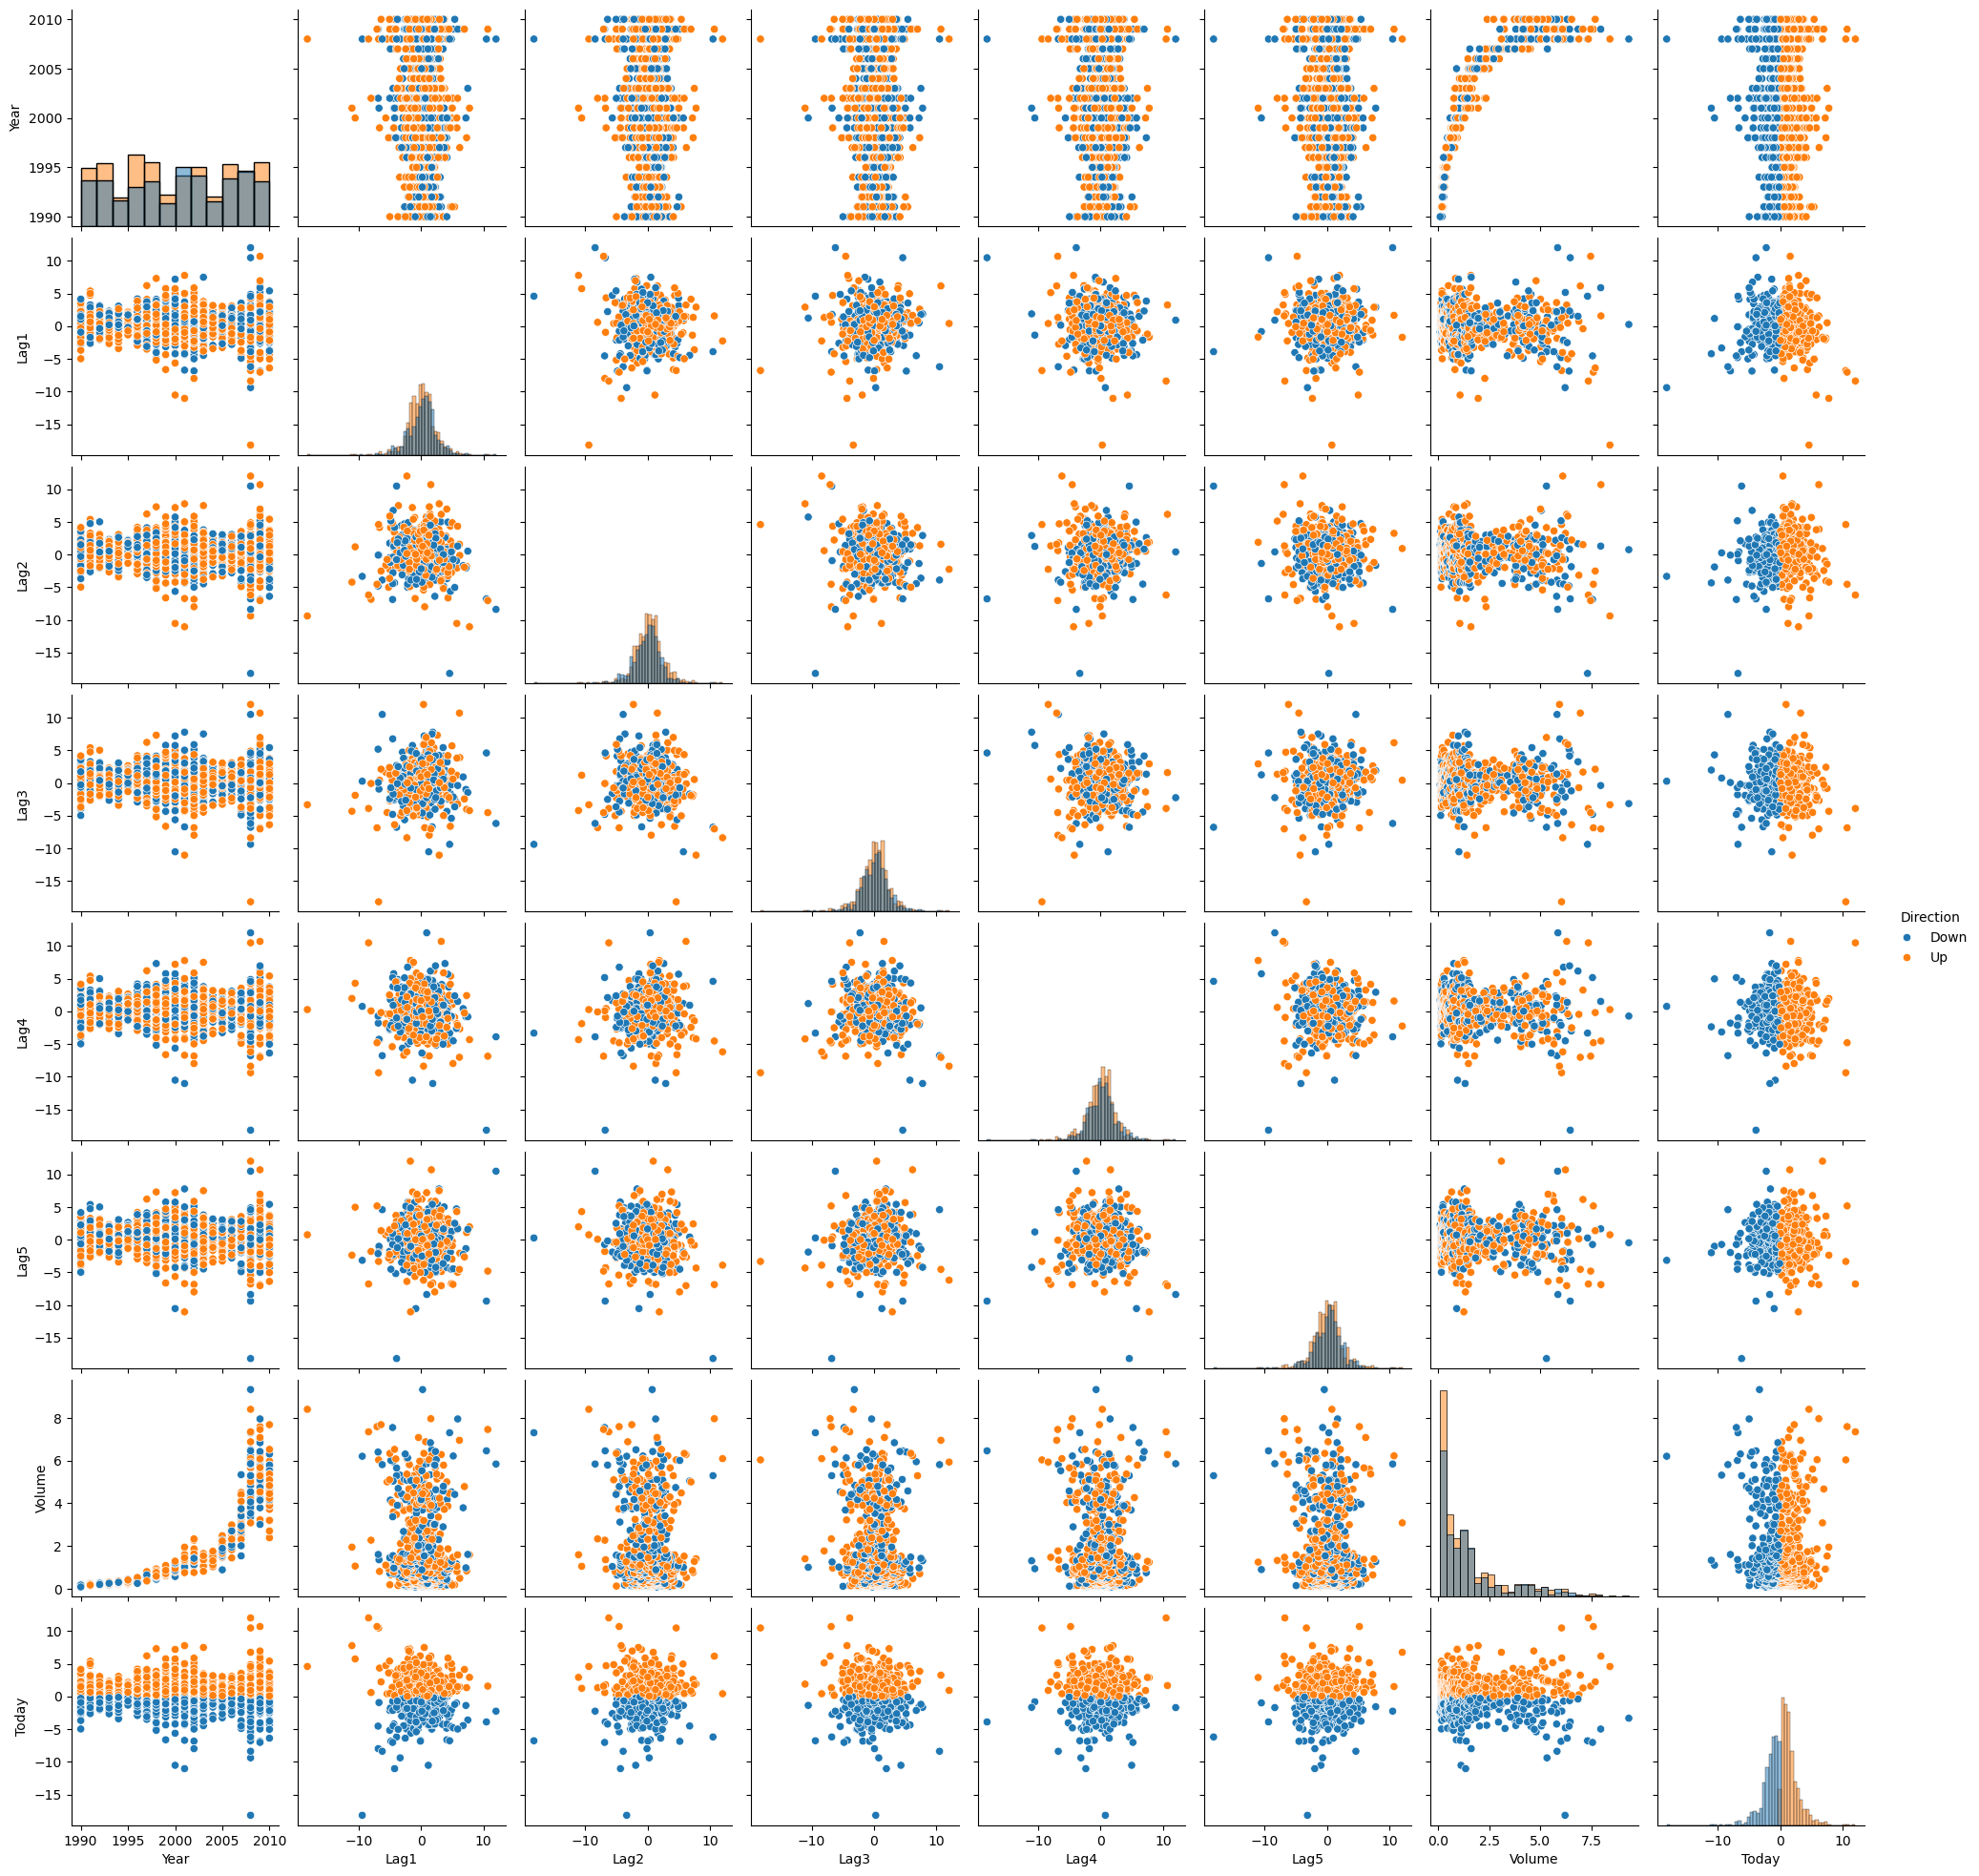

In [17]:
from ISLP import load_data
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
Weekly = load_data('Weekly')

# Numerical summary
print(Weekly.describe())

# Correlation matrix (numeric columns only)
print(Weekly.select_dtypes(include=['number']).corr())

# Pairplot (works fine because hue is categorical)
sns.pairplot(Weekly, hue='Direction', diag_kind='hist')
plt.show()

## (b) Logistic Regression (Full Dataset)

In [18]:
import statsmodels.api as sm
from sklearn.preprocessing import LabelEncoder

X = Weekly[['Lag1','Lag2','Lag3','Lag4','Lag5','Volume']]
y = LabelEncoder().fit_transform(Weekly['Direction'])  # Up=1, Down=0

X = sm.add_constant(X)
model = sm.Logit(y, X).fit()
print(model.summary())

Optimization terminated successfully.
         Current function value: 0.682441
         Iterations 4
                           Logit Regression Results                           
Dep. Variable:                      y   No. Observations:                 1089
Model:                          Logit   Df Residuals:                     1082
Method:                           MLE   Df Model:                            6
Date:                Sun, 15 Feb 2026   Pseudo R-squ.:                0.006580
Time:                        21:56:13   Log-Likelihood:                -743.18
converged:                       True   LL-Null:                       -748.10
Covariance Type:            nonrobust   LLR p-value:                    0.1313
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.2669      0.086      3.106      0.002       0.098       0.435
Lag1          -0.0413      0.

## (c) Confusion Matrix (Full Data)

In [19]:
from sklearn.metrics import confusion_matrix, accuracy_score

pred_prob = model.predict(X)
pred_class = (pred_prob > 0.5).astype(int)

confusion_matrix(y, pred_class)
accuracy_score(y, pred_class)

0.5610651974288338

## (d) Logistic Regression (Train: 1990–2008, Test: 2009–2010)

In [20]:
train = Weekly[Weekly['Year'] < 2009]
test = Weekly[Weekly['Year'] >= 2009]

X_train = sm.add_constant(train[['Lag2']])
X_test = sm.add_constant(test[['Lag2']])

y_train = LabelEncoder().fit_transform(train['Direction'])
y_test = LabelEncoder().fit_transform(test['Direction'])

log_model = sm.Logit(y_train, X_train).fit()

pred_prob = log_model.predict(X_test)
pred_class = (pred_prob > 0.5).astype(int)

confusion_matrix(y_test, pred_class)
accuracy_score(y_test, pred_class)


Optimization terminated successfully.
         Current function value: 0.685555
         Iterations 4


0.625

## (e) LDA

In [21]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

lda = LinearDiscriminantAnalysis()
lda.fit(train[['Lag2']], y_train)

lda_pred = lda.predict(test[['Lag2']])

confusion_matrix(y_test, lda_pred)
accuracy_score(y_test, lda_pred)

0.625

## (f) QDA

In [22]:
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis

qda = QuadraticDiscriminantAnalysis()
qda.fit(train[['Lag2']], y_train)

qda_pred = qda.predict(test[['Lag2']])

confusion_matrix(y_test, qda_pred)
accuracy_score(y_test, qda_pred)

0.5865384615384616

## (g) KNN (K = 1)

In [23]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=1)
knn.fit(train[['Lag2']], y_train)

knn_pred = knn.predict(test[['Lag2']])

confusion_matrix(y_test, knn_pred)
accuracy_score(y_test, knn_pred)

0.5

## (h) Naive Bayes

In [24]:
from sklearn.naive_bayes import GaussianNB

nb = GaussianNB()
nb.fit(train[['Lag2']], y_train)

nb_pred = nb.predict(test[['Lag2']])

confusion_matrix(y_test, nb_pred)
accuracy_score(y_test, nb_pred)

0.5865384615384616

## (i) Which method performs best?

In [25]:
from sklearn.metrics import accuracy_score

results = {}

# Logistic (Lag2 only)
results["Logistic"] = accuracy_score(y_test, pred_class)

# LDA
results["LDA"] = accuracy_score(y_test, lda_pred)

# QDA
results["QDA"] = accuracy_score(y_test, qda_pred)

# KNN (K=1)
results["KNN (K=1)"] = accuracy_score(y_test, knn_pred)

# Naive Bayes
results["Naive Bayes"] = accuracy_score(y_test, nb_pred)

results

{'Logistic': 0.625,
 'LDA': 0.625,
 'QDA': 0.5865384615384616,
 'KNN (K=1)': 0.5,
 'Naive Bayes': 0.5865384615384616}

## (j) Experimenting With Predictors & K

### (j) Logistic With Lag1 + Lag2

In [26]:
import statsmodels.api as sm

X_train2 = sm.add_constant(train[['Lag1','Lag2']])
X_test2 = sm.add_constant(test[['Lag1','Lag2']])

log2 = sm.Logit(y_train, X_train2).fit()
pred2 = (log2.predict(X_test2) > 0.5).astype(int)

accuracy_score(y_test, pred2)

Optimization terminated successfully.
         Current function value: 0.683735
         Iterations 4


0.5769230769230769

### Polynomial Term (Lag2²)

In [27]:
train = Weekly[Weekly['Year'] < 2009].copy()
test = Weekly[Weekly['Year'] >= 2009].copy()

train['Lag2_sq'] = train['Lag2']**2
test['Lag2_sq'] = test['Lag2']**2

X_train_poly = sm.add_constant(train[['Lag2','Lag2_sq']])
X_test_poly = sm.add_constant(test[['Lag2','Lag2_sq']])

log_poly = sm.Logit(y_train, X_train_poly).fit()
pred_poly = (log_poly.predict(X_test_poly) > 0.5).astype(int)

accuracy_score(y_test, pred_poly)

Optimization terminated successfully.
         Current function value: 0.684992
         Iterations 4


0.625

### KNN With Multiple K Values

In [28]:
from sklearn.neighbors import KNeighborsClassifier

knn_results = {}

for k in [1,3,5,7,9,11]:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(train[['Lag2']], y_train)
    pred = knn.predict(test[['Lag2']])
    knn_results[k] = accuracy_score(y_test, pred)

knn_results

{1: 0.5,
 3: 0.5480769230769231,
 5: 0.5384615384615384,
 7: 0.5480769230769231,
 9: 0.5480769230769231,
 11: 0.5576923076923077}

### Best Model

In [29]:
all_results = {
    "Logistic (Lag2)": results["Logistic"],
    "Logistic (Lag1+Lag2)": accuracy_score(y_test, pred2),
    "Logistic (Lag2 + Lag2^2)": accuracy_score(y_test, pred_poly),
    **{f"KNN (K={k})": v for k, v in knn_results.items()}
}

all_results

{'Logistic (Lag2)': 0.625,
 'Logistic (Lag1+Lag2)': 0.5769230769230769,
 'Logistic (Lag2 + Lag2^2)': 0.625,
 'KNN (K=1)': 0.5,
 'KNN (K=3)': 0.5480769230769231,
 'KNN (K=5)': 0.5384615384615384,
 'KNN (K=7)': 0.5480769230769231,
 'KNN (K=9)': 0.5480769230769231,
 'KNN (K=11)': 0.5576923076923077}